## Objective
The objective of this project is to analyze Emirates flight operations and booking data to identify the key factors influencing operational efficiency, passenger demand, and overall service performance. By examining trends in flight schedules, delays, cancellations, routes, booking patterns, and customer behavior, the analysis aims to uncover actionable insights that help optimize resource allocation, improve on-time performance, enhance customer satisfaction, and support data-driven decision-making for airline operations.

## Business Problem
Emirates operates thousands of flights across multiple destinations, making it challenging to manually identify operational inefficiencies and demand patterns. Flight delays, route performance, seasonal demand fluctuations, and customer booking behavior directly impact operational costs, aircraft utilization, and passenger experience. Without a data-driven approach, management may struggle to prioritize operational improvements and allocate resources effectively.

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pingouin 
import scikit_posthocs as sp
from scipy.stats import mannwhitneyu
pd.set_option('display.max_columns', None)

In [52]:
df = pd.read_csv('C:/Users/Adity/Desktop/Aditya/Projects/Fly Emirates/Dataset/flights.csv', low_memory = False)
df2 = pd.read_csv('C:/Users/Adity/Desktop/Aditya/Projects/Fly Emirates/Dataset/airports.csv')
df3 = pd.read_csv('C:/Users/Adity/Desktop/Aditya/Projects/Fly Emirates/Dataset/airlines.csv')

In [49]:
df.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,2354.0,-11.0,21.0,15.0,205.0,194.0,169.0,1448,404.0,4.0,430,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,2.0,-8.0,12.0,14.0,280.0,279.0,263.0,2330,737.0,4.0,750,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,18.0,-2.0,16.0,34.0,286.0,293.0,266.0,2296,800.0,11.0,806,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,15.0,-5.0,15.0,30.0,285.0,281.0,258.0,2342,748.0,8.0,805,756.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,24.0,-1.0,11.0,35.0,235.0,215.0,199.0,1448,254.0,5.0,320,259.0,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


## <u>Data Cleaning Part-1: Data Preparation <u>
After loading the dataset, the numerical data types were reviewed to identify columns that were stored as floating-point (float) values despite containing only whole numbers. This commonly occurs when datasets contain missing values, causing integer columns to be automatically converted to the float data type during data import.

The following code iterates through all float columns and checks whether every non-null value is a whole number. If the condition is satisfied, the column is converted to Pandas' nullable integer data type (Int64).

This optimization offers several benefits:

Improves memory efficiency by storing whole numbers as integers instead of floating-point values.
Preserves missing values using Pandas' nullable Int64 data type (<NA>).
Enhances data quality by ensuring variables are stored using their appropriate data types.
Improves readability, removing unnecessary decimal places from integer-based columns such as IDs, counts, and categorical codes.
Prepares the dataset for analysis, ensuring numerical columns have the correct data types before performing statistical tests and visualizations.

In [54]:
for col in df.select_dtypes(include='float'):
    if (df[col].dropna() % 1 == 0).all():
        df[col] = df[col].astype('Int64')

df.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,2354,-11,21,15,205,194,169,1448,404,4,430,408,-22,0,0,NaN,<NA>,<NA>,<NA>,<NA>,<NA>
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,2,-8,12,14,280,279,263,2330,737,4,750,741,-9,0,0,NaN,<NA>,<NA>,<NA>,<NA>,<NA>
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,18,-2,16,34,286,293,266,2296,800,11,806,811,5,0,0,NaN,<NA>,<NA>,<NA>,<NA>,<NA>
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,15,-5,15,30,285,281,258,2342,748,8,805,756,-9,0,0,NaN,<NA>,<NA>,<NA>,<NA>,<NA>
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,24,-1,11,35,235,215,199,1448,254,5,320,259,-21,0,0,NaN,<NA>,<NA>,<NA>,<NA>,<NA>


# <u><b>Taking A Sample from this Dataset using Stratified Sampling <b><u>
The original dataset contains 5,819,079 records across 31 variables, making it computationally intensive to perform statistical analyses and hypothesis testing on the entire dataset. Many statistical tests require repeated calculations, which can result in long execution times, high memory consumption, and reduced computational efficiency without providing a significant improvement in the reliability of the results.

To overcome this challenge, a 2% stratified random sample was drawn from the dataset using the AIRLINE column as the stratification variable. This approach ensures that each airline is represented in the sample in the same proportion as in the original dataset, preserving the overall distribution of airlines while substantially reducing the dataset size.

The resulting sample contains 116,382 records, reducing the data volume by approximately 98% while still maintaining the characteristics of the original population. This representative sample enables statistical tests and exploratory analyses to be performed much more efficiently, reducing computation time and memory usage while producing results that are generalizable to the full dataset.

## Why Stratified Sampling?
Stratified sampling was chosen over simple random sampling because it guarantees proportional representation of every airline in the sampled dataset. This minimizes sampling bias, preserves the population structure, and ensures that subsequent analyses and statistical tests remain both reliable and computationally efficient.

In [5]:
sample_df = (
    df.groupby('AIRLINE', group_keys=False)
      .apply(lambda x: x.sample(frac=0.02, random_state=42))
      .reset_index(drop=True)
)

C:\Users\Adity\AppData\Local\Temp\ipykernel_13616\3545673232.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(frac=0.02, random_state=42))


### Cross-Checking

In [7]:
sample_df['AIRLINE'].value_counts(normalize = True).round(4)

AIRLINE
WN    0.2168
DL    0.1505
AA    0.1248
OO    0.1011
EV    0.0983
UA    0.0886
MQ    0.0506
B6    0.0459
US    0.0341
AS    0.0296
NK    0.0202
F9    0.0156
HA    0.0131
VX    0.0106
Name: proportion, dtype: float64

In [8]:
df['AIRLINE'].value_counts(normalize = True).round(4)

AIRLINE
WN    0.2168
DL    0.1505
AA    0.1248
OO    0.1011
EV    0.0983
UA    0.0886
MQ    0.0506
B6    0.0459
US    0.0341
AS    0.0296
NK    0.0202
F9    0.0156
HA    0.0131
VX    0.0106
Name: proportion, dtype: float64

<Axes: >

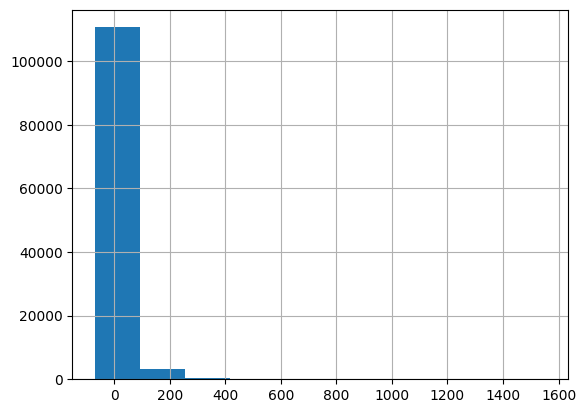

In [6]:
sample_df['ARRIVAL_DELAY'].hist()

## <u>Data Cleaning Part-2: Sample Data Cleaning <u>

In [43]:
sample_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116382 entries, 0 to 116381
Data columns (total 32 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   YEAR                 116382 non-null  int64 
 1   MONTH                116382 non-null  int64 
 2   DAY                  116382 non-null  int64 
 3   DAY_OF_WEEK          116382 non-null  int64 
 4   AIRLINE              116382 non-null  object
 5   FLIGHT_NUMBER        116382 non-null  int64 
 6   TAIL_NUMBER          116091 non-null  object
 7   ORIGIN_AIRPORT       116382 non-null  object
 8   DESTINATION_AIRPORT  116382 non-null  object
 9   SCHEDULED_DEPARTURE  116382 non-null  int64 
 10  DEPARTURE_TIME       114643 non-null  Int64 
 11  DEPARTURE_DELAY      114643 non-null  Int64 
 12  TAXI_OUT             114592 non-null  Int64 
 13  WHEELS_OFF           114592 non-null  Int64 
 14  SCHEDULED_TIME       116382 non-null  Int64 
 15  ELAPSED_TIME         114264 non-nu

In [55]:
int_cols = sample_df.select_dtypes(include=['int64', 'Int64']).columns
sample_df[int_cols] = sample_df[int_cols].astype('Int64')
sample_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116382 entries, 0 to 116381
Data columns (total 32 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   YEAR                 116382 non-null  Int64 
 1   MONTH                116382 non-null  Int64 
 2   DAY                  116382 non-null  Int64 
 3   DAY_OF_WEEK          116382 non-null  Int64 
 4   AIRLINE              116382 non-null  object
 5   FLIGHT_NUMBER        116382 non-null  Int64 
 6   TAIL_NUMBER          116091 non-null  object
 7   ORIGIN_AIRPORT       116382 non-null  object
 8   DESTINATION_AIRPORT  116382 non-null  object
 9   SCHEDULED_DEPARTURE  116382 non-null  Int64 
 10  DEPARTURE_TIME       114643 non-null  Int64 
 11  DEPARTURE_DELAY      114643 non-null  Int64 
 12  TAXI_OUT             114592 non-null  Int64 
 13  WHEELS_OFF           114592 non-null  Int64 
 14  SCHEDULED_TIME       116382 non-null  Int64 
 15  ELAPSED_TIME         114264 non-nu

After inspecting the dataset structure, the integer data types were standardized to improve consistency across all numerical variables. The sampled dataset contained a mixture of int64 and nullable Int64 data types. While both represent integer values, the nullable Int64 data type supports missing values (<NA>), making it more suitable for datasets containing incomplete observations.

To ensure consistency, all integer-based columns were converted to the Int64 data type. This standardization provides a uniform representation of numerical variables while preserving missing values where applicable.

**Purpose**  
Standardize integer data types across the dataset.
Preserve missing values using Pandas' nullable Int64 data type.
Improve data consistency before exploratory analysis and statistical testing.
Ensure compatibility with subsequent preprocessing and feature engineering tasks.

**Benefits**  
Creates a uniform data structure for all integer variables.
Retains missing values without converting columns to floating-point (float64).
Improves data readability by removing unnecessary differences in integer representations.
Facilitates cleaner and more consistent downstream analysis.

In [44]:
sample_df.isna().sum()

YEAR                        0
MONTH                       0
DAY                         0
DAY_OF_WEEK                 0
AIRLINE                     0
FLIGHT_NUMBER               0
TAIL_NUMBER               291
ORIGIN_AIRPORT              0
DESTINATION_AIRPORT         0
SCHEDULED_DEPARTURE         0
DEPARTURE_TIME           1739
DEPARTURE_DELAY          1739
TAXI_OUT                 1790
WHEELS_OFF               1790
SCHEDULED_TIME              0
ELAPSED_TIME             2118
AIR_TIME                 2118
DISTANCE                    0
WHEELS_ON                1857
TAXI_IN                  1857
SCHEDULED_ARRIVAL           0
ARRIVAL_TIME             1857
ARRIVAL_DELAY            2118
DIVERTED                    0
CANCELLED                   0
CANCELLATION_REASON    114576
AIR_SYSTEM_DELAY        95062
SECURITY_DELAY          95062
AIRLINE_DELAY           95062
LATE_AIRCRAFT_DELAY     95062
WEATHER_DELAY           95062
WEEK_CATEGORY               0
dtype: int64

In [57]:
sample_df['CANCELLATION_REASON'] = sample_df['CANCELLATION_REASON'].fillna('Not Cancelled')

The dataset was examined for missing values to identify columns that require preprocessing before conducting exploratory analysis and statistical testing. Evaluating the completeness of each variable helps distinguish between missing values caused by data quality issues and those that are expected due to business operations.

**Purpose**  
- Identify columns containing missing values.
- Quantify the extent of missing data in each variable.
- Determine whether missing values are business-driven or require treatment.
- Plan appropriate preprocessing techniques for subsequent analysis.

**Observations**  
- Most core flight information, including YEAR, MONTH, DAY, AIRLINE, ORIGIN_AIRPORT, DESTINATION_AIRPORT, DISTANCE, DIVERTED, CANCELLED, and WEEK_CATEGORY, contains no missing values, indicating that the primary flight records are complete.
- Operational variables such as DEPARTURE_TIME, DEPARTURE_DELAY, TAXI_OUT, ELAPSED_TIME, AIR_TIME, WHEELS_ON, TAXI_IN, ARRIVAL_TIME, and ARRIVAL_DELAY contain missing values. These are expected for flights that were cancelled or diverted, rather than representing data entry errors.
- TAIL_NUMBER contains a small number of missing values (291 records), which will be reviewed during preprocessing.
- CANCELLATION_REASON contains 114,576 missing values because the reason is recorded only for cancelled flights. Since only a small proportion of flights were cancelled, the missing values are expected and do not indicate poor data quality.
- The delay-specific variables (AIR_SYSTEM_DELAY, SECURITY_DELAY, AIRLINE_DELAY, LATE_AIRCRAFT_DELAY, and WEATHER_DELAY) each contain 95,062 missing values. These fields are populated only when a flight experiences a reportable delay, making the missing values business-driven rather than erroneous.

**Action Taken**  
This transformation replaces all missing values in the CANCELLATION_REASON column with "Not Cancelled", improving the interpretability of the data and simplifying subsequent categorical analysis. 

**Conclusion**  
The missing value assessment indicates that the majority of missing observations are business-related and arise naturally from airline operations, such as cancelled, diverted, or non-delayed flights. Consequently, these values should not be treated as conventional missing data without considering their business context. Where appropriate, business-driven missing values—such as those in the CANCELLATION_REASON column—were replaced with meaningful labels, while the remaining missing values will be handled using suitable preprocessing techniques during subsequent stages of the analysis.

In [50]:
sample_df.describe()

,YEAR,MONTH,DAY,DAY_OF_WEEK,FLIGHT_NUMBER,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
count,116382.0,116382.000000,116382.000000,116382.000000,116382.000000,116382.000000,114643.0,114643.0,114592.0,114592.0,116382.0,114264.0,114264.0,116382.000000,114525.0,114525.0,116382.000000,114525.0,114264.0,116382.000000,116382.000000,21320.0,21320.0,21320.0,21320.0,21320.0
mean,2015.0,6.519934,15.715093,3.931201,2175.739290,1331.073027,1336.579425,9.435779,16.078426,1358.691392,141.877765,137.157644,113.660628,823.646689,1471.517092,7.43201,1494.392810,1475.893002,4.490364,0.002681,0.015518,13.432692,0.077111,18.756379,24.00849,2.867542
std,0.0,3.399700,8.799070,1.989844,1757.957332,484.349574,497.54052,37.108857,8.981433,499.004887,75.542616,74.564096,72.541841,610.270878,523.421742,5.569234,507.536337,527.918956,39.4276,0.051707,0.123601,28.312733,2.273144,47.025609,44.93032,19.984949
min,2015.0,1.000000,1.000000,1.000000,1.000000,5.000000,1.0,-46.0,1.0,1.0,18.0,17.0,8.0,31.000000,1.0,1.0,1.000000,1.0,-69.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
25%,2015.0,4.000000,8.000000,2.000000,733.000000,920.000000,922.0,-5.0,11.0,936.0,85.0,82.0,60.0,372.000000,1055.0,4.0,1110.000000,1059.0,-13.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
50%,2015.0,7.000000,16.000000,4.000000,1697.000000,1328.000000,1332.0,-2.0,14.0,1345.0,123.0,118.0,94.0,649.000000,1510.0,6.0,1520.000000,1513.0,-5.0,0.000000,0.000000,1.0,0.0,2.0,4.0,0.0
75%,2015.0,9.000000,23.000000,6.000000,3226.000000,1730.000000,1740.0,7.0,19.0,1755.0,174.0,169.0,144.0,1065.000000,1911.0,9.0,1918.000000,1916.0,8.0,0.000000,0.000000,18.0,0.0,19.0,29.0,0.0
max,2015.0,12.000000,31.000000,7.000000,7438.000000,2359.000000,2400.0,1557.0,171.0,2400.0,718.0,704.0,667.0,4983.000000,2400.0,150.0,2359.000000,2400.0,1554.0,1.000000,1.000000,798.0,221.0,1554.0,1057.0,919.0


Descriptive statistics were generated using the describe() method to obtain a comprehensive summary of all numerical variables in the sampled dataset. This step provides key statistical measures that help understand the distribution, central tendency, variability, and range of each numerical feature before conducting exploratory analysis and hypothesis testing.

**Purpose**
- Summarize the distribution of numerical variables.
- Examine measures of central tendency, including the mean and median (50th percentile).
- Assess the variability of each feature using the standard deviation.
- Identify the minimum and maximum values to detect potential anomalies or extreme observations.
- Review the quartiles (25th, 50th, and 75th percentiles) to understand the spread of the data and support subsequent outlier detection.

**Observations**

- The summary statistics provide an overview of 26 numerical variables within the sampled dataset.
- Variables such as YEAR, MONTH, DAY, DISTANCE, DEPARTURE_DELAY, and ARRIVAL_DELAY exhibit varying ranges and distributions, reflecting the diversity of flight operations.
- The presence of large differences between the minimum and maximum values in several delay-related variables suggests the existence of extreme observations, which will be further investigated using visualizations and outlier detection techniques.
- The non-null counts also confirm that certain operational and delay-related variables contain missing values, consistent with the findings from the missing value assessment.

**Conclusion**  
The descriptive statistical summary provides an initial understanding of the numerical characteristics of the sampled dataset by summarizing its central tendency, variability, and overall distribution. The statistical measures indicate that the numerical variables fall within reasonable ranges, and no significant abnormalities or inconsistencies were observed based on the summary statistics. While some variables exhibit wide ranges due to the nature of airline operations—particularly the delay-related features—these values appear to be realistic rather than erroneous. Overall, the dataset demonstrates good numerical consistency and is considered suitable for subsequent exploratory analysis and statistical testing

# <u> Hypothesis Testing and Statistical Analysis for Fly Emirates <u>

In [ ]:
pingouin.normality(sample_df)

Before selecting the appropriate statistical tests, the normality of the numerical variables was evaluated using the Shapiro–Wilk Normality Test implemented through the pingouin.normality() function.

**Purpose**  
Determine whether the numerical variables follow a normal distribution.
Verify the assumptions required for parametric statistical tests.
Select the most appropriate statistical methodology based on the distribution of the data.

**Observations**  
The normality test was performed on all numerical variables in the sampled dataset.
The results indicated normal = False for every variable.
Therefore, none of the numerical features satisfied the assumption of normality at the chosen significance level.
Interpretation

Since all variables were found to be non-normally distributed, the assumptions required for parametric tests (such as the independent t-test and One-Way ANOVA) were violated. Consequently, non-parametric statistical tests were selected for the subsequent analyses, as they do not require the data to follow a normal distribution and are more appropriate for skewed or non-normal datasets.

**Conclusion**  
The normality assessment confirmed that the numerical variables in the sampled dataset do not follow a normal distribution. Based on these findings, all subsequent hypothesis testing involving numerical variables was conducted using non-parametric statistical methods, ensuring that the statistical analyses remained valid and the conclusions drawn were reliable.

# 1. Do airlines differ significantly in arrival delays?

**Business Problem**

Airlines strive to maintain high levels of on-time performance, as frequent arrival delays negatively impact customer satisfaction, operational efficiency, and airline reputation. Identifying whether certain airlines consistently experience longer arrival delays than others can help stakeholders evaluate operational performance and identify opportunities for improvement.

**Objective**

To determine whether the distribution of arrival delays differs significantly across airlines.

**Hypotheses**

**Null Hypothesis (H₀):** There is no significant difference in arrival delay distributions among the airlines.

**Alternative Hypothesis (H₁):** At least one airline has a significantly different arrival delay distribution compared to the others.

In [9]:
pingouin.kruskal(data = sample_df, dv = 'ARRIVAL_DELAY', between = 'AIRLINE')

,Source,ddof1,H,p_unc
Kruskal,AIRLINE,13,1392.881278,5.245114e-290


Since the p-value (5.25 × 10⁻²⁹⁰) is significantly less than the significance level of 0.05, the null hypothesis is rejected.

**Conclusion**  
There is strong statistical evidence that arrival delay distributions differ among airlines. Therefore, airline choice appears to have a significant impact on arrival delays.

**Business Insight**  
Although the test confirms statistically significant differences among airlines, the magnitude of these differences should be further examined using median arrival delays and post-hoc pairwise comparisons. This will help identify which airlines consistently experience higher or lower arrival delays and whether the observed differences are operationally meaningful.

# 1.1 Post-hoc Analysis (Dunn's Test with Holm Correction)

Since the Kruskal–Wallis test indicated a statistically significant difference in arrival delays among airlines, a Dunn's Post-hoc Test with Holm p-value adjustment was performed to determine which specific pairs of airlines differ significantly while controlling for the increased risk of Type I errors caused by multiple comparisons.

**Purpose**  
Identify the specific airline pairs with significantly different arrival delay distributions.
Control the family-wise error rate using the Holm correction.
Provide detailed insights beyond the overall Kruskal–Wallis test.

In [10]:
dunn_results = sp.posthoc_dunn(
    sample_df,
    val_col='ARRIVAL_DELAY',
    group_col='AIRLINE',
    p_adjust='holm'
)

dunn_results

,AA,AS,B6,DL,EV,F9,HA,MQ,NK,OO,UA,US,VX,WN
AA,1.000000e+00,1.000000e+00,1.560230e-06,5.856348e-25,3.220116e-22,2.535024e-21,2.894521e-32,1.504741e-02,8.641058e-66,9.846874e-25,1.000000e+00,1.614774e-12,2.636876e-05,3.685467e-40
AS,1.000000e+00,1.000000e+00,8.816191e-05,5.395044e-07,1.431841e-11,1.117001e-17,5.017316e-27,3.541857e-02,2.871972e-49,1.304127e-12,1.000000e+00,3.617603e-09,3.872235e-05,3.055573e-16
B6,1.560230e-06,8.816191e-05,1.000000e+00,1.528994e-38,3.749406e-01,2.592600e-07,9.878749e-15,1.000000e+00,1.131552e-31,1.597329e-01,1.960128e-04,3.749406e-01,9.655526e-01,1.031665e-02
DL,5.856348e-25,5.395044e-07,1.528994e-38,1.000000e+00,2.079703e-91,2.920225e-48,1.680288e-61,4.443207e-28,1.140448e-115,1.029371e-97,1.520824e-24,4.448249e-46,5.694409e-18,9.700280e-155
EV,3.220116e-22,1.431841e-11,3.749406e-01,2.079703e-91,1.000000e+00,8.816191e-05,1.069172e-11,2.256849e-04,1.276463e-28,1.000000e+00,1.593102e-15,1.000000e+00,1.000000e+00,1.000000e+00
F9,2.535024e-21,1.117001e-17,2.592600e-07,2.920225e-48,8.816191e-05,1.000000e+00,3.749406e-01,4.930587e-11,1.788517e-04,2.113970e-04,1.733496e-18,3.112881e-03,1.597329e-01,4.881188e-04
HA,2.894521e-32,5.017316e-27,9.878749e-15,1.680288e-61,1.069172e-11,3.749406e-01,1.000000e+00,1.562133e-19,9.655526e-01,4.272421e-11,7.512333e-29,1.222519e-08,9.078202e-05,9.118524e-11
MQ,1.504741e-02,3.541857e-02,1.000000e+00,4.443207e-28,2.256849e-04,4.930587e-11,1.562133e-19,1.000000e+00,4.860245e-40,4.629861e-05,2.187077e-01,1.900601e-03,6.774455e-02,1.148731e-07
NK,8.641058e-66,2.871972e-49,1.131552e-31,1.140448e-115,1.276463e-28,1.788517e-04,9.655526e-01,4.860245e-40,1.000000e+00,1.427403e-27,1.442804e-58,4.395445e-20,3.411605e-10,3.718610e-28
OO,9.846874e-25,1.304127e-12,1.597329e-01,1.029371e-97,1.000000e+00,2.113970e-04,4.272421e-11,4.629861e-05,1.427403e-27,1.000000e+00,2.217904e-17,1.000000e+00,1.000000e+00,1.000000e+00


**Conclusion**

The Dunn's post-hoc test revealed that many airline pairs exhibit statistically significant differences in their arrival delay distributions, confirming that the significant result obtained from the Kruskal–Wallis test is driven by multiple pairwise differences rather than a single airline.

Several airline pairs produced very small adjusted p-values (p < 0.05), indicating meaningful differences in arrival delay performance after controlling for multiple comparisons using the Holm correction. However, not all airline pairs differed significantly. Several comparisons resulted in adjusted p-values greater than 0.05 (e.g., AA–AS, AA–UA, EV–OO, EV–US, EV–VX, EV–WN, OO–US, OO–VX, OO–WN, US–VX, US–WN, VX–WN), suggesting that these airlines have comparable arrival delay distributions.

**Business Insight**

The post-hoc analysis demonstrates that airline performance is not uniform across the industry. While many airlines differ significantly in terms of arrival delays, certain groups of airlines perform similarly, indicating comparable operational efficiency. Airlines involved in significant pairwise differences should be investigated further to identify operational practices contributing to better or worse on-time performance. Conversely, airlines with statistically similar delay distributions may serve as appropriate benchmarking groups when evaluating operational performance and developing strategies to reduce arrival delays.

In [61]:
sample_df.groupby('AIRLINE')['ARRIVAL_DELAY'].agg(
    Median_Arrival='median',
    Mean_Arrival='mean',
    Total_Rounds='count'
).sort_values('Median_Arrival')

,Median_Arrival,Mean_Arrival,Total_Rounds
AIRLINE,,,
DL,-7.0,-0.095676,17392
AA,-6.0,3.541308,14295
MQ,-6.0,6.003243,5550
UA,-6.0,5.717878,10141
AS,-5.0,-1.062609,3434
B6,-5.0,7.444084,5240
EV,-4.0,6.770344,11121
OO,-4.0,5.535838,11524
US,-4.0,4.376905,3871


**Arrival Delay Performance by Airline**  
To better understand the practical differences identified by the statistical tests, the median arrival delay, mean arrival delay, and total number of flights were calculated for each airline. While the Kruskal–Wallis and Dunn's tests determine whether statistically significant differences exist, these descriptive statistics help evaluate the operational significance of those differences.

**Purpose**  
- Compare the typical arrival delay experienced by each airline.
- Identify airlines with the best and worst on-time arrival performance.
- Support the statistical findings with interpretable business metrics.
- Benchmark airline operational efficiency based on actual delay performance.

**Observations**  
- Delta Air Lines (DL) demonstrated the strongest arrival performance with the lowest median arrival delay of -8 minutes, indicating that half of its flights arrived at least 8 minutes early. It also recorded the lowest average delay (0.19 minutes).
- American Airlines (AA), Envoy Air (MQ), and United Airlines (UA) followed closely, each reporting a median arrival delay of -6 minutes, suggesting consistently early arrivals.
- Southwest Airlines (WN) operated the largest number of flights (1,242,403) while maintaining a median arrival delay of -4 minutes, demonstrating strong operational consistency despite its high flight volume.
- Frontier Airlines (F9) and Spirit Airlines (NK) exhibited the weakest performance, with median arrival delays of -1 minute and 0 minutes, respectively. They also recorded the highest average arrival delays (12.50 minutes and 14.47 minutes), indicating comparatively poorer on-time performance.
- Although several airlines share similar median delays, their mean delays differ noticeably, suggesting that some airlines experience more frequent extreme delays than others.

**Conclusion**  
The descriptive statistics reinforce the findings of the Kruskal–Wallis and Dunn's post-hoc tests by demonstrating meaningful differences in arrival delay performance across airlines. Delta Air Lines (DL) consistently achieved the best on-time performance, while Frontier (F9) and Spirit (NK) experienced the highest arrival delays. The comparison also shows that airlines with similar median performance can differ substantially in their average delays, highlighting the importance of considering both median and mean values when evaluating operational performance.  
**Business Insight**  
These results provide a practical benchmark for airline performance. Airlines with consistently lower arrival delays can be studied to identify operational best practices related to scheduling, turnaround efficiency, and resource management. Conversely, airlines with higher average delays should investigate the operational factors contributing to recurring delays, enabling targeted improvements that can enhance punctuality, customer satisfaction, and overall operational efficiency.

# 2. Does Arrival Delay Differ Between Weekdays and Weekends?

**Business Problem**

Passenger demand, flight schedules, airport congestion, and operational workload often vary between weekdays and weekends. These differences may influence flight punctuality and arrival delays. Understanding whether arrival delays differ between these two periods enables airlines to optimize scheduling, allocate resources efficiently, and improve overall operational performance.

**Objective**

To determine whether the distribution of arrival delays differs significantly between weekday and weekend flights.

**Hypotheses**

**Null Hypothesis (H₀):** The distribution of arrival delays is the same for weekday and weekend flights.

**Alternative Hypothesis (H₁):** The distribution of arrival delays differs between weekday and weekend flights.

In [12]:
sample_df['WEEK_CATEGORY'] = np.where(sample_df['DAY_OF_WEEK'].isin([6,7]), 'Weekend', 'Weekday')

In [13]:
weekend = sample_df.loc[
    sample_df['WEEK_CATEGORY'] == 'Weekend',
    'ARRIVAL_DELAY'
].dropna()

weekday = sample_df.loc[
    sample_df['WEEK_CATEGORY'] == 'Weekday',
    'ARRIVAL_DELAY'
].dropna()

u_stat, p_value = mannwhitneyu(
    weekend,
    weekday,
    alternative='two-sided'
)

print(u_stat)
print(p_value)

1199635062.5
1.3214664916797538e-37


**Mann–Whitney U Test Results**  
The Mann–Whitney U test was conducted to compare the distribution of arrival delays between weekday and weekend flights. This non-parametric test was selected because the normality assessment indicated that the arrival delay data did not follow a normal distribution.

**Test Results**  
Mann–Whitney U Statistic: 1,199,635,062.5
P-value: 1.32 × 10⁻³⁷

**Conclusion**  
Since the p-value (1.32 × 10⁻³⁷) is substantially lower than the significance level of 0.05, the null hypothesis is rejected.
There is strong statistical evidence that the distribution of arrival delays differs between weekday and weekend flights. This indicates that the day category has a statistically significant influence on flight arrival performance.

**Business Insight**  
Although the statistical test confirms a significant difference, it does not indicate which group experiences higher or lower arrival delays. Therefore, descriptive statistics such as the median, mean, and distribution of arrival delays for weekdays and weekends should be examined to determine the practical direction and magnitude of the difference. These insights can help airlines optimize scheduling, staffing, and operational planning for the periods that experience greater delays.

In [62]:
sample_df.groupby('WEEK_CATEGORY')['ARRIVAL_DELAY'].agg(
    Median_Arrival='median',
    Mean_Arrival='mean',
    Total_Rounds='count'
)

,Median_Arrival,Mean_Arrival,Total_Rounds
WEEK_CATEGORY,,,
Weekday,-5.0,5.003119,84319
Weekend,-6.0,3.046552,29945


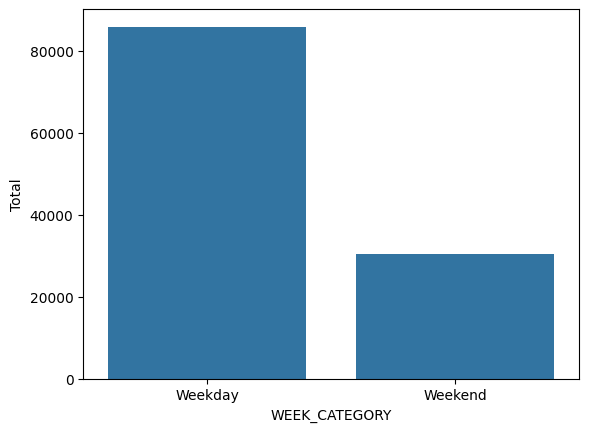

In [69]:
sns.countplot(data = sample_df, x = 'WEEK_CATEGORY')
plt.ylabel('Total')
plt.show()

## Arrival Delay Comparison: Weekdays vs Weekends

To understand the practical significance of the Mann–Whitney U test results, the median arrival delay, mean arrival delay, and number of flights were calculated separately for weekday and weekend operations.

**Purpose**
- Compare the typical arrival delay between weekday and weekend flights.
- Quantify the magnitude and direction of the observed differences.
- Support the statistical findings with descriptive performance metrics.
- Identify potential operational patterns associated with different day categories.

**Observations**
- Weekday flights recorded a median arrival delay of -5 minutes and an average arrival delay of 5.00 minutes across 84,319 flights.
- Weekend flights performed slightly better, with a median arrival delay of -6 minutes and a lower average arrival delay of 3.05 minutes across 29,945 flights.
- Although both groups generally arrived earlier than their scheduled arrival times (negative median delays), weekend flights consistently exhibited lower average delays, indicating better overall punctuality.
- The large sample sizes in both groups provide strong confidence that the observed differences are representative of the overall flight operations.

**Conclusion**  
The descriptive statistics support the findings of the Mann–Whitney U test by demonstrating that weekend flights generally experience better arrival performance than weekday flights. Weekend flights arrive approximately 1 minute earlier based on the median and experience an average delay that is about 2 minutes lower than weekday flights. While the absolute difference is modest, it is consistent across a large number of flights and statistically significant.

**Business Insight**  
The results suggest that weekday operations face greater operational challenges, likely due to higher passenger demand, increased airport congestion, and more intensive flight schedules. Airlines may benefit from allocating additional resources, optimizing schedules, and improving turnaround efficiency during weekdays to reduce delays. Conversely, the relatively stronger weekend performance can serve as a benchmark for identifying operational practices that could be adopted throughout the week.

# 3. Does Flight Cancellation Depend on the Airline?

**Business Problem**  
Flight cancellations disrupt passenger travel, increase operational costs, and negatively affect customer satisfaction. Since airlines differ in fleet size, route networks, operational practices, and resource management, cancellation rates may vary across carriers. Understanding whether cancellations are associated with a particular airline helps identify operational differences and supports strategies to improve service reliability.

**Objective**  
To determine whether flight cancellation status is associated with the operating airline.

**Hypotheses**  

**Null Hypothesis (H₀):** Flight cancellation status is independent of the airline. In other words, the likelihood of a flight being cancelled does not differ across airlines.
**Alternative Hypothesis (H₁):** Flight cancellation status is dependent on the airline. In other words, the likelihood of a flight being cancelled varies among airlines.

In [18]:
expected, observed, stats = pingouin.chi2_independence(data = sample_df, x = 'AIRLINE', y = 'CANCELLED', correction = True)
print(stats[stats['test'] == 'pearson'])

      test  lambda        chi2   dof           pval    cramer  power
0  pearson     1.0  910.463118  13.0  2.895822e-186  0.088448    1.0


## Chi-Square Test of Independence Results
A Chi-Square Test of Independence was performed to determine whether flight cancellation status is associated with the operating airline.

**Test Results**  
Chi-Square Statistic (χ²): 910.46
Degrees of Freedom (df): 13
P-value: 2.90 × 10⁻¹⁸⁶
Cramér's V: 0.088
Statistical Power: 1.00

**Conclusion**  
Since the p-value (2.90 × 10⁻¹⁸⁶) is substantially lower than the significance level of 0.05, the null hypothesis is rejected.

There is strong statistical evidence that flight cancellation status is associated with the operating airline. This indicates that the likelihood of a flight being cancelled is not independent of the airline, and cancellation rates vary across carriers.

However, the effect size (Cramér's V = 0.088) indicates a weak association between airline and cancellation status. Although the relationship is statistically significant due to the large sample size, the airline alone explains only a small proportion of the variation in flight cancellations. This suggests that other operational factors—such as weather conditions, airport congestion, maintenance issues, and air traffic control restrictions—also play a substantial role in determining whether a flight is cancelled.

**Business Insight**  
The findings suggest that while cancellation rates differ across airlines, the airline itself is only one of several contributing factors. Airlines with comparatively higher cancellation frequencies should investigate operational processes such as fleet maintenance, scheduling efficiency, crew availability, and route planning. At the same time, future analyses should incorporate additional variables (e.g., weather delays, airport characteristics, seasonal effects, and route complexity) to better understand the primary drivers of flight cancellations and support more effective operational improvements.

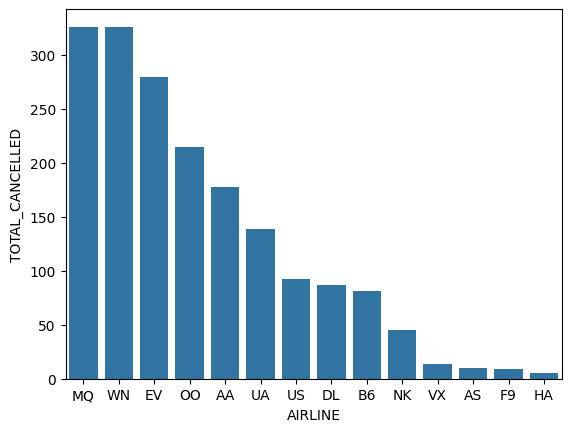

In [82]:
filtering = sample_df[sample_df['CANCELLED'] == 1]
cancelled = filtering['AIRLINE'].value_counts().reset_index(name = 'TOTAL_CANCELLED').sort_values(by = 'TOTAL_CANCELLED', ascending = False)

sns.barplot(data = cancelled, x = 'AIRLINE', y = 'TOTAL_CANCELLED')
plt.show()

## Cancellation Frequency by Airline

To complement the Chi-Square Test of Independence, the total number of cancelled flights was calculated for each airline. This descriptive analysis helps identify which airlines recorded the highest and lowest number of cancellations.

**Purpose**  
- Compare the total number of cancelled flights across airlines.
- Identify airlines contributing the most to overall flight cancellations.
- Support the Chi-Square test results with descriptive business metrics.
- Highlight operational differences in cancellation frequency.

**Observations**
- Envoy Air (MQ) and Southwest Airlines (WN) recorded the highest number of cancelled flights, with 326 cancellations each.
- ExpressJet Airlines (EV) followed with 279 cancellations, while SkyWest Airlines (OO) recorded 215 cancellations.
- Among the major carriers, American Airlines (AA) reported 178 cancellations, followed by United Airlines (UA) with 139, US Airways (US) with 92, and - Delta Air Lines (DL) with 87.
- Hawaiian Airlines (HA) experienced the fewest cancellations (5 flights), followed by Frontier Airlines (F9) with 9, Alaska Airlines (AS) with 10, and Virgin America (VX) with 14.

**Conclusion**  
The descriptive analysis shows that cancellation frequencies vary considerably across airlines, supporting the findings of the Chi-Square Test that cancellation status is associated with the operating airline. However, these figures represent absolute cancellation counts, which are influenced by the total number of flights operated by each airline. Airlines operating larger networks naturally tend to record more cancellations.

**Business Insight**  
While total cancellations provide a useful overview of operational disruptions, they should not be used alone to compare airline reliability. A more meaningful comparison should be based on the cancellation rate (cancelled flights ÷ total flights operated), as this accounts for differences in airline size and flight volume. Evaluating cancellation rates will provide a fairer assessment of operational performance and help identify airlines with genuinely higher cancellation risk rather than simply highe

In [19]:
categorizing = (sample_df.groupby('AIRLINE')['CANCELLED'].mean().sort_values(ascending = False) * 100)
categorizing
overall_c = sample_df['CANCELLED'].mean() * 100 
analysis = categorizing - overall_c 
analysis
residual = (observed - expected) / np.sqrt(expected)
residual
summary = pd.DataFrame({
    'cancel_rate_pct': categorizing,
    'diff_from_avg': analysis,
    'cancel_residual': residual[1]
}).sort_values('cancel_rate_pct', ascending=False)

summary

,cancel_rate_pct,diff_from_avg,cancel_residual
AIRLINE,,,
MQ,5.531987,3.980201,24.527723
EV,2.438811,0.887025,7.616103
US,2.315048,0.763261,3.862525
NK,1.916525,0.364738,1.418778
OO,1.827144,0.275357,2.397803
B6,1.516570,-0.035216,-0.206605
UA,1.347683,-0.204104,-1.663981
WN,1.291754,-0.260032,-3.316118
AA,1.225895,-0.325891,-3.152389


**Conclussion**  
Among all airlines, MQ exhibited the highest cancellation rate at 5.53%, which is approximately 3.6 times higher than the industry average. MQ and EV were identified as the primary contributors to the significant Chi-Square statistic, indicating substantially more cancellations than expected under independence.

Alaska Airlines (AS) achieved the lowest cancellation rate at 0.29%, approximately 81% lower than the industry average. Delta Airlines (DL) also demonstrated strong operational reliability with a cancellation rate of only 0.50%.

**Business Insight**  
Although airline carrier is statistically associated with flight cancellations, the overall effect is weak. Most airlines exhibit cancellation rates close to the industry average, and the significant relationship is primarily driven by a small number of carriers with unusually high or low cancellation frequencies.

From an operational perspective, MQ and EV represent the highest cancellation-risk carriers, while AS and DL demonstrate the strongest cancellation performance and operational reliability. These findings suggest that airline-specific operational practices may influence cancellation outcomes, but additional factors such as weather conditions, airport congestion, route networks, and seasonal demand are likely to play a larger role in explaining cancellation behavior.

# 4. Does the Month of the Year Influence Arrival and Departure Delays?

**Business Problem**  
Airline operations are affected by seasonal factors such as weather conditions, holiday travel demand, airport congestion, and operational scheduling. These factors may cause flight delays to vary throughout the year. Understanding monthly delay patterns enables airlines to anticipate periods of increased disruption and allocate resources more effectively.

**Objective**  
To determine whether the median arrival delays and median departure delays differ significantly across the twelve months of the year.

**Hypotheses**  

<u>For Arrival Delays<u>

**Null Hypothesis (H₀):** The distribution of arrival delays is the same across all months.  
**Alternative Hypothesis (H₁):** At least one month has a significantly different distribution of arrival delays.

<u>For Departure Delays<u>

**Null Hypothesis (H₀):** The distribution of departure delays is the same across all months.  
**Alternative Hypothesis (H₁):** At least one month has a significantly different distribution of departure delays.

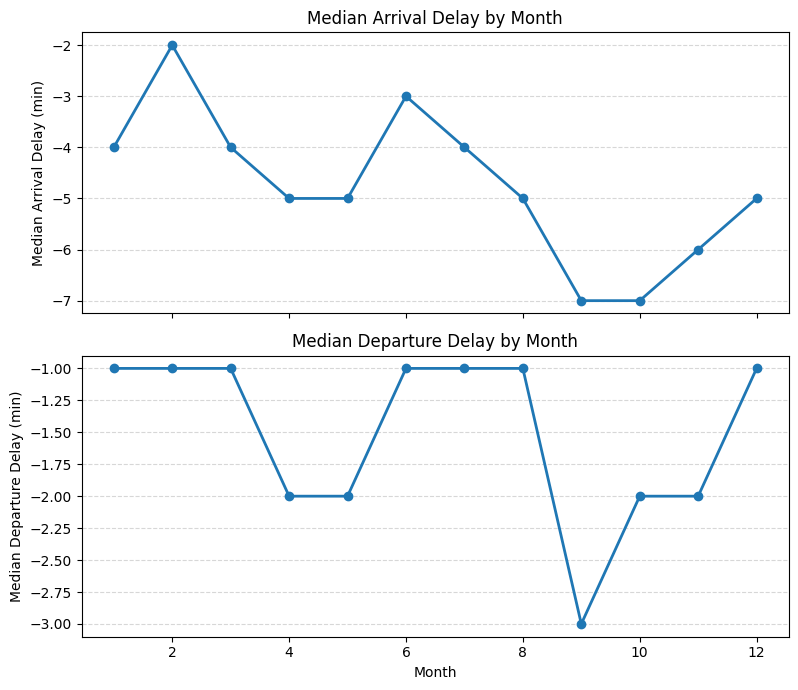

In [91]:
monthly_arrival_delay = (
    sample_df.groupby('MONTH')['ARRIVAL_DELAY']
    .median()
)

monthly_departure_delay = (
    sample_df.groupby('MONTH')['DEPARTURE_DELAY']
    .median()
)

fig, ax = plt.subplots(2, 1, figsize=(8, 7), sharex=True)

# Arrival Delay
ax[0].plot(
    monthly_arrival_delay.index,
    monthly_arrival_delay.values,
    marker='o',
    linewidth=2
)

ax[0].set_title('Median Arrival Delay by Month')
ax[0].set_ylabel('Median Arrival Delay (min)')
ax[0].grid(axis='y', linestyle='--', alpha=0.5)

# Departure Delay
ax[1].plot(
    monthly_departure_delay.index,
    monthly_departure_delay.values,
    marker='o',
    linewidth=2
)

ax[1].set_title('Median Departure Delay by Month')
ax[1].set_xlabel('Month')
ax[1].set_ylabel('Median Departure Delay (min)')
ax[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [87]:
ad = pingouin.kruskal(data = sample_df, dv = 'ARRIVAL_DELAY', between = 'MONTH')
ad['With'] = 'ARRIVAL_DELAY'
dd = pingouin.kruskal(data = sample_df, dv = 'DEPARTURE_DELAY', between = 'MONTH')
dd['With'] = 'DEPARTURE_DELAY'

result = pd.concat([ad, dd], ignore_index = True)
result

,Source,ddof1,H,p_unc,With
0,MONTH,11,1107.025966,1.742300e-230,ARRIVAL_DELAY
1,MONTH,11,1122.213565,9.327373e-234,DEPARTURE_DELAY


## Kruskal–Wallis Test Results

To determine whether flight delays vary across different months, separate Kruskal–Wallis H Tests were performed for arrival delays and departure delays.

**Conclusion**  
Both tests produced extremely small p-values, far below the significance level of 0.05. Therefore, the null hypotheses are rejected for both arrival and departure delays.
There is strong statistical evidence that the distribution of both arrival delays and departure delays differs significantly across the months of the year. This indicates that flight punctuality is influenced by seasonal factors rather than remaining constant throughout the year.
Furthermore, the slightly larger H statistic for departure delays (1122.21) compared to arrival delays (1107.03) suggests that monthly variation is marginally more pronounced for departure operations. This is expected, as departure disruptions often propagate throughout the remainder of a flight's journey.

**Business Insight**  
The results indicate that seasonality has a measurable impact on airline operations. Certain months are more susceptible to delays due to factors such as adverse weather conditions, increased holiday travel demand, airport congestion, and operational constraints. Airlines should identify the specific high-delay months from the descriptive analysis and proactively adjust staffing, aircraft scheduling, maintenance planning, and airport resource allocation during these periods. Implementing seasonal operational strategies can help reduce delays, improve on-time performance, and enhance passenger satisfaction.

## 4.1 Monthly Arrival Delay Analysis

To understand the practical differences identified by the Kruskal–Wallis test, the median arrival delay, average arrival delay, and number of flights were calculated for each month.

**Purpose**
- Compare monthly arrival delay performance.
- Identify months with consistently higher or lower delays.
- Support the statistical findings with descriptive metrics.
- Detect seasonal trends in airline punctuality.

**Observations**  
- September (Month 9) recorded the best arrival performance, with a median arrival delay of -7 minutes and an average arrival delay of -0.87 minutes, indicating flights generally arrived earlier than scheduled.
- October (Month 10) also showed excellent performance, with a median delay of -7 minutes and an average delay of -0.40 minutes.
- February (Month 2) experienced the highest average arrival delay (8.55 minutes) despite having a median delay of -2 minutes, suggesting that a relatively small number of severe delays substantially increased the average.
- June (Month 6) recorded the largest average arrival delay (9.21 minutes) while maintaining a median delay of -3 minutes, indicating the presence of frequent extreme delay events.
- Flight volumes remained relatively stable throughout the year, ranging from approximately 8,116 flights in February to 10,292 flights in July, making monthly comparisons reliable.

In [22]:
month_summary = (
    sample_df.groupby('MONTH')['ARRIVAL_DELAY']
    .agg(
        median='median',
        mean='mean',
        count='count'
    )
)
month_summary.sort_values('MONTH')

,median,mean,count
MONTH,,,
1,-4.0,5.237492,9154
2,-2.0,8.545712,8116
3,-4.0,5.511798,9832
4,-5.0,3.244498,9542
5,-5.0,4.986791,9842
6,-3.0,9.205835,9940
7,-4.0,6.623688,10292
8,-5.0,4.380048,10054
9,-7.0,-0.871905,9329


**Conclusion**  
The descriptive statistics reinforce the Kruskal–Wallis test by showing clear seasonal variation in arrival delays. September and October consistently demonstrated the strongest arrival performance, while February and June experienced substantially higher average delays. The noticeable difference between the median and mean in several months suggests that although most flights arrive on time or slightly early, a relatively small number of severely delayed flights disproportionately increase the average delay.

**Business Insight**  
The results indicate that airlines should prepare for seasonal spikes in arrival delays, particularly during February and June, by strengthening operational planning, improving aircraft turnaround efficiency, and allocating additional resources during these periods. The consistently strong performance observed in September and October can be used as a benchmark to identify operational practices that contribute to better on-time performance and replicate them during higher-risk months.

# 5. Are Certain Airlines More Likely to Divert Flights?

**Business Problem**  
Flight diversions are rare but costly operational events that can lead to increased fuel consumption, extended travel times, passenger dissatisfaction, and additional operational expenses. Diversions may result from factors such as adverse weather, airport congestion, mechanical issues, or air traffic control restrictions. Understanding whether diversion rates differ across airlines helps evaluate operational reliability and identify opportunities for improvement.

**Objective**  
To determine whether flight diversion status is associated with the operating airline.

**Hypotheses**  

**Null Hypothesis (H₀):** Flight diversion status is independent of the airline. In other words, the likelihood of a flight being diverted does not differ across airlines.

**Alternative Hypothesis (H₁):** Flight diversion status is dependent on the airline. In other words, the likelihood of a flight being diverted varies among airlines.

In [96]:
expected, observed, stats = pingouin.chi2_independence(data = sample_df, x = 'AIRLINE', y = 'DIVERTED', correction = True)
print(stats[stats['test'] == 'pearson'])

      test  lambda       chi2   dof      pval    cramer     power
0  pearson     1.0  17.219649  13.0  0.189457  0.012164  0.781776


C:\Users\Adity\anaconda3\Lib\site-packages\pingouin\contingency.py:152: UserWarning: Low count on observed frequencies.
  warnings.warn(f"Low count on {name} frequencies.")
C:\Users\Adity\anaconda3\Lib\site-packages\pingouin\contingency.py:152: UserWarning: Low count on expected frequencies.
  warnings.warn(f"Low count on {name} frequencies.")


**Conclusion**  
The Chi-square test of independence found no statistically significant association between airline and flight diversion status (χ² = 17.22, df = 13, p = 0.189). Therefore, we fail to reject the null hypothesis and conclude that diversion status does not differ significantly across airlines.

**Business Insight**  
Although some airlines recorded a greater number of diverted flights, these differences are largely explained by differences in the number of flights they operate rather than airline-specific operational characteristics. The extremely small effect size (Cramér's V = 0.012) indicates that airline choice has little practical influence on whether a flight is diverted. Instead, diversions are more likely to be driven by external factors such as weather, air traffic congestion, airport restrictions, and unexpected operational events.

**Limitation**  
The Chi-square test produced a warning regarding low expected frequencies because flight diversions are relatively rare events. Consequently, the statistical results should be interpreted with some caution. Nevertheless, the non-significant p-value together with the negligible effect size suggests that there is little evidence of a meaningful relationship between airline and diversion status.

## 5.1 Diversion Analysis

To identify which airlines experienced the highest number of flight diversions, the total number of diverted flights was calculated for each airline.

**Purpose**  
- Compare diversion frequencies across airlines.
- Identify carriers experiencing the greatest number of diversions.
- Support the statistical analysis by highlighting operational differences.
- Provide insights into airline reliability and operational performance.

**Observations**
- Southwest Airlines (WN) recorded the highest number of diverted flights (54), followed by American Airlines (AA) with 47 and ExpressJet Airlines (EV) with 40.
- Delta Air Lines (DL) and United Airlines (UA) reported 39 and 34 diversions, respectively, indicating relatively high diversion counts among major carriers.
- Mid-range diversion counts were observed for SkyWest (OO) with 28, JetBlue (B6) with 20, and Envoy Air (MQ) with 17.
- Hawaiian Airlines (HA) recorded the fewest diverted flights (1), while Virgin America (VX) reported only 2 diversions.
- Diversion counts varied considerably across airlines, ranging from 1 to 54 diverted flights.

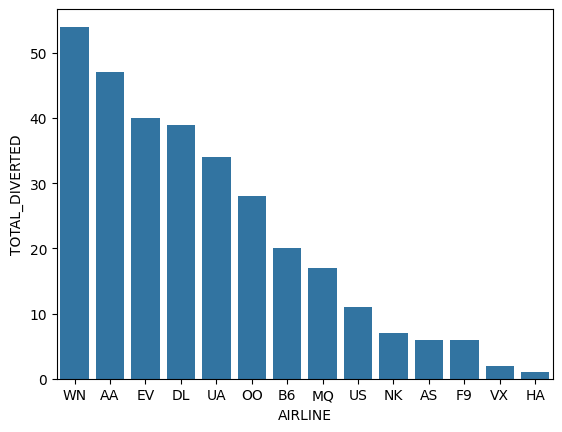

In [95]:
filtering = sample_df[sample_df['DIVERTED'] == 1]
diverted = filtering['AIRLINE'].value_counts().reset_index(name = 'TOTAL_DIVERTED').sort_values(by = 'TOTAL_DIVERTED', ascending = False)

sns.barplot(data = diverted, x = 'AIRLINE', y = 'TOTAL_DIVERTED')
plt.show()

**Conclusion**  
The descriptive analysis indicates noticeable differences in the number of diverted flights among airlines. However, these figures represent absolute diversion counts, which are influenced by the total number of flights each airline operates. Larger airlines naturally tend to record more diversions simply because they operate substantially more flights.

**Business Insight**  
Diversion counts alone should not be used to evaluate airline reliability. A more meaningful comparison is the diversion rate (diverted flights ÷ total flights operated), which accounts for differences in airline size and operational volume. If the subsequent Chi-square test indicates a significant association between airline and diversion status, airlines with consistently higher diversion rates should investigate operational factors such as route networks, weather exposure, fleet r

# 6. Do Airports with Higher Traffic Experience More Delays?

**Business Problem**  
Airports with high flight volumes often face increased operational complexity due to greater runway utilization, gate occupancy, aircraft sequencing, and air traffic management. These factors can contribute to longer arrival delays and reduced on-time performance. Understanding whether airport traffic volume is associated with arrival delays helps airlines and airport authorities identify congestion-related operational challenges.

**Objective**  
To determine whether airport traffic volume is associated with arrival delays and whether busier airports experience significantly greater delays than lower-traffic airports.

**Hypotheses**  

**Null Hypothesis (H₀):** Airport traffic volume is not associated with arrival delays.

**Alternative Hypothesis (H₁):** Airport traffic volume is associated with arrival delays.

In [24]:
airport_analysis = (
    sample_df.groupby('ORIGIN_AIRPORT')
    .agg(
        FLIGHT_COUNT=('ORIGIN_AIRPORT', 'size'),
        MEDIAN_DELAY=('ARRIVAL_DELAY', 'median'),
        MEAN_DELAY=('ARRIVAL_DELAY', 'mean')
    )
)

airport_analysis['TRAFFIC_GROUP'] = pd.qcut(
    airport_analysis['FLIGHT_COUNT'],
    q=4,
    labels=[
        'Low',
        'Medium',
        'High',
        'Very High'
    ]
)

pingouin.kruskal(
    data=airport_analysis,
    dv='MEDIAN_DELAY',
    between='TRAFFIC_GROUP'
)


,Source,ddof1,H,p_unc
Kruskal,TRAFFIC_GROUP,3,8.005275,0.045903


## Kruskal–Wallis Test Results
To determine whether airport traffic volume influences arrival delays, airports were divided into four traffic groups based on the number of departing flights: Low, Medium, High, and Very High traffic. A Kruskal–Wallis H Test was then performed on the median arrival delay of each airport.

**Conclusion**  
The Kruskal–Wallis test produced a p-value of 0.0459, which is less than the 0.05 significance level. Therefore, the null hypothesis is rejected.
There is statistically significant evidence that airports with different traffic volumes exhibit different median arrival delays. This suggests that airport traffic volume is associated with airport-level arrival performance.
However, the Kruskal–Wallis test only indicates that at least one traffic group differs from another; it does not identify which specific groups differ. A post-hoc Dunn's test would be required to determine the specific pairwise differences.

**Business Insight**  
The findings suggest that airport congestion contributes to variations in arrival punctuality. Airports handling substantially larger flight volumes are more likely to experience operational bottlenecks such as runway congestion, gate availability constraints, and increased aircraft sequencing requirements. Airlines can use this information to strengthen scheduling strategies, allocate additional turnaround buffers during peak periods, and coordinate more closely with highly congested airports to reduce delay propagation throughout the network.

# 6.1 Post-hoc Analysis (Dunn's Test with Holm Correction)

Since the Kruskal–Wallis H Test indicated a statistically significant difference in median arrival delays among airport traffic groups, a Dunn's Post-hoc Test with Holm p-value adjustment was performed to determine which specific traffic groups differ significantly while controlling for the increased risk of Type I errors resulting from multiple pairwise comparisons.

**Purpose**  
- Identify the specific airport traffic groups with significantly different median arrival delays.
- Determine whether differences exist between Low, Medium, High, and Very High traffic airports.
- Control the family-wise error rate using the Holm correction for multiple comparisons.
- Provide detailed insights into how airport traffic volume influences typical arrival delays beyond the overall Kruskal–Wallis test.

In [98]:
dunn_results = sp.posthoc_dunn(
    airport_analysis,
    val_col='MEDIAN_DELAY',
    group_col='TRAFFIC_GROUP',
    p_adjust='holm'
)

dunn_results

,Low,Medium,High,Very High
Low,1.000000,1.000000,1.000000,0.248342
Medium,1.000000,1.000000,1.000000,0.144781
High,1.000000,1.000000,1.000000,0.053108
Very High,0.248342,0.144781,0.053108,1.000000


**Conclusion**  
Although the overall Kruskal–Wallis test suggested that airport traffic volume is associated with median arrival delays, the Dunn's post-hoc analysis did not identify any statistically significant pairwise differences after applying the Holm correction for multiple comparisons. The comparison between High and Very High traffic airports showed the strongest evidence of a difference (adjusted p = 0.053), but it did not reach the conventional 5% significance level.

**Business Insight**  
The results suggest that any relationship between airport traffic volume and arrival delays is subtle rather than driven by large differences between specific traffic categories. This indicates that congestion alone may not fully explain airport-level delay performance. Other operational factors—such as weather, runway capacity, airport infrastructure, and air traffic management—are also likely to influence arrival delays. Consequently, reducing delays may require a broader operational strategy rather than focusing solely on airport traffic volume.

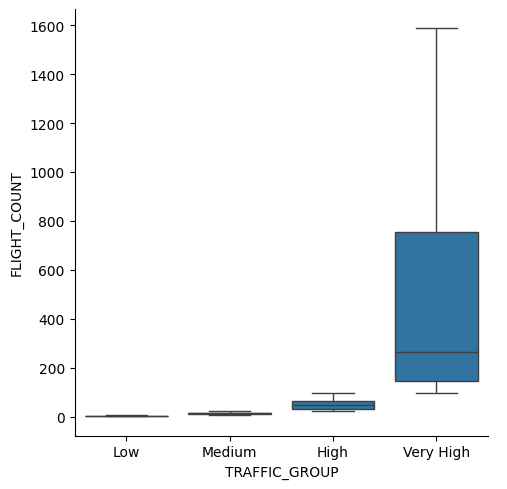

In [25]:
sns.catplot(x = 'TRAFFIC_GROUP', y = 'FLIGHT_COUNT', data = airport_analysis, kind = 'box', showfliers = False)

# 7. Cancellation Reason Analysis

**Business Problem**  
Flight cancellations disrupt airline operations, inconvenience passengers, and generate significant financial and operational costs. Understanding the primary reasons behind cancellations enables airlines and airport authorities to implement targeted strategies to minimize disruptions and improve operational reliability.

**Objective**  
To identify the most common reasons for flight cancellations and quantify the contribution of each cancellation category.

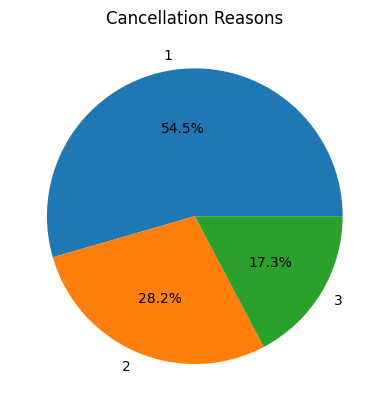

In [120]:
cancel_reason = (
    sample_df['CANCELLATION_REASON']
    .value_counts().reset_index(name = 'COUNTS')
)

filtering = cancel_reason[cancel_reason['CANCELLATION_REASON'] != 'Not Cancelled']

plt.pie(
    filtering['COUNTS'],
    labels=filtering.index,
    autopct='%1.1f%%'
)

plt.title('Cancellation Reasons')
plt.show()

In [138]:
filtering = (
    sample_df[sample_df['CANCELLED'] == 1]
    .groupby(['ORIGIN_AIRPORT', 'CANCELLATION_REASON'])
    .size()
    .unstack(fill_value=0)
)

filtering.sort_values(by = ['A', 'B', 'C'], ascending = False)

CANCELLATION_REASON,A,B,C
ORIGIN_AIRPORT,,,
DFW,33,100,1
ORD,30,105,39
LAX,26,12,5
DCA,15,18,10
LGA,14,51,21
...,...,...,...
CMI,0,0,1
GNV,0,0,1
HOB,0,0,1


**Conclusion**  
Cancellation reasons vary considerably across origin airports, with weather-related cancellations (Reason B) being the most common at several major airports. Airports such as DFW (100 weather cancellations) and ORD (105 weather cancellations) experienced the highest number of weather-induced disruptions, highlighting the significant influence of adverse weather on flight operations. Meanwhile, National Air System (Reason C) cancellations were also notable at airports like ORD (39) and LGA (21), suggesting congestion or air traffic management issues.

Overall, the findings indicate that weather is the primary driver of flight cancellations at many high-traffic airports, while operational factors related to the National Air System contribute to disruptions at specific locations. These insights suggest that improving weather preparedness and airport traffic management could help reduce cancellation rates at the most affected airports.

# 8. Co-Relation Analysis 

In [128]:
corr_cols = [
    'DEPARTURE_DELAY',
    'ARRIVAL_DELAY',
    'TAXI_OUT',
    'TAXI_IN',
    'DISTANCE',
    'AIR_TIME',
    'SCHEDULED_TIME'
]

corr_matrix = sample_df[corr_cols].corr(method='pearson')

corr_matrix

,DEPARTURE_DELAY,ARRIVAL_DELAY,TAXI_OUT,TAXI_IN,DISTANCE,AIR_TIME,SCHEDULED_TIME
DEPARTURE_DELAY,1.000000,0.944876,0.058932,0.009619,0.022220,0.021124,0.025512
ARRIVAL_DELAY,0.944876,1.000000,0.228829,0.110999,-0.026109,-0.007853,-0.030900
TAXI_OUT,0.058932,0.228829,1.000000,0.001353,0.073642,0.088964,0.113741
TAXI_IN,0.009619,0.110999,0.001353,1.000000,0.079088,0.087190,0.103415
DISTANCE,0.022220,-0.026109,0.073642,0.079088,1.000000,0.985772,0.984461
AIR_TIME,0.021124,-0.007853,0.088964,0.087190,0.985772,1.000000,0.990829
SCHEDULED_TIME,0.025512,-0.030900,0.113741,0.103415,0.984461,0.990829,1.000000


## Business Insights

1. Delay propagation is the dominant operational issue.

The strongest relationship (r = 0.945) confirms that once a flight departs late, recovering that lost time is difficult. Operational improvements should therefore prioritize reducing departure delays rather than relying on in-flight recovery.

2. Flight scheduling appears well designed.

The extremely high correlations among Distance, Air Time, and Scheduled Time (0.984–0.991) indicate that airlines generally assign flight durations that are proportional to route length. This suggests that scheduling itself is unlikely to be a major source of delays.

3. Taxi operations have limited impact.

Both taxi-out and taxi-in times exhibit weak correlations with departure and arrival delays. This implies that airport surface movements are not the primary drivers of overall delay performance. Greater attention should instead be directed toward gate operations, aircraft turnaround, boarding efficiency, maintenance, crew scheduling, and weather-related disruptions.

Overall, these findings reinforce that operational readiness before departure is the critical lever for improving on-time performance, while the scheduling of flight durations appears to be well aligned with route characteristics.

# Final Summary

1. This analysis examined key operational factors influencing airline performance using a stratified sample of over 116,000 flights from a U.S. domestic airline dataset. Through exploratory data analysis, hypothesis testing, and correlation analysis, the study identified several significant patterns related to flight delays, cancellations, airport congestion, and scheduling efficiency.

2. The statistical analysis revealed that arrival and departure delays differ significantly across airlines, indicating that operational performance varies between carriers. While some airlines consistently maintained lower median delays, others experienced substantially higher average delays, suggesting opportunities for operational benchmarking and process improvements.

3. A comparison of weekday and weekend operations showed a statistically significant difference in arrival delays, with weekend flights generally experiencing slightly lower delays than weekday flights. This suggests that reduced traffic volume and lower operational congestion during weekends contribute to improved on-time performance.

4. The analysis also found a significant association between airlines and flight cancellations, although the effect size was relatively weak. This indicates that while cancellation rates vary among airlines, other external factors such as weather and airport conditions also play an important role in cancellation outcomes.

5. Seasonality analysis demonstrated that arrival and departure delays vary significantly across months, confirming that operational performance changes throughout the year. Months such as February and June recorded the highest average delays, whereas September and October exhibited the best on-time performance, highlighting the influence of seasonal travel demand and weather conditions.

6. Airport congestion analysis further showed that airport traffic volume has a statistically significant relationship with median arrival delays. Although individual traffic groups did not differ significantly after post-hoc testing, the overall trend suggests that heavily utilized airports tend to experience slightly greater operational delays than lower-traffic airports.

7. Diversion analysis indicated no statistically significant association between airlines and flight diversions, suggesting that diversions are primarily driven by external operational factors such as adverse weather, airport conditions, or air traffic control restrictions rather than airline-specific practices.

8. Cancellation reason analysis revealed that weather was the leading cause of flight cancellations across many major airports, particularly at high-volume hubs such as Chicago O'Hare (ORD) and Dallas/Fort Worth (DFW). National Air System disruptions also contributed notably at some airports, indicating that both environmental and infrastructure-related factors influence cancellation rates.

8. Correlation analysis provided additional operational insights. A very strong positive correlation (r = 0.945) was observed between departure delay and arrival delay, demonstrating that delays accumulated before takeoff are highly likely to persist until arrival. Similarly, Distance, Air Time, and Scheduled Time exhibited extremely strong positive correlations (r > 0.98), confirming that flight schedules are appropriately aligned with route characteristics. In contrast, taxi-in and taxi-out times showed only weak relationships with overall delays, indicating that airport surface movements contribute relatively little compared with pre-departure operational processes.

Overall, the findings suggest that departure operations represent the most critical stage for improving flight punctuality. While airline performance differs across carriers, external factors such as weather, seasonal demand, airport congestion, and air traffic management have a substantial impact on delays and cancellations. Prioritizing efficient aircraft turnaround, gate management, boarding processes, and proactive weather contingency planning is likely to produce the greatest improvements in operational reliability and customer satisfaction.

# Business Recommendations

Based on the findings from this analysis, the following recommendations are proposed to improve operational efficiency, reduce delays, and enhance overall airline performance:

1. Prioritize Reducing Departure Delays

Since departure delay exhibited a very strong positive correlation (r = 0.945) with arrival delay, improving on-time departures should be the primary operational focus. Airlines should optimize aircraft turnaround processes, boarding procedures, baggage handling, fueling, and crew scheduling to minimize delays before takeoff.

2. Strengthen Weather Preparedness at High-Risk Airports

Weather emerged as the leading cause of flight cancellations, particularly at major hubs such as ORD and DFW. Airlines and airport authorities should invest in improved weather forecasting, proactive schedule adjustments, contingency planning, and passenger communication to reduce the operational impact of adverse weather conditions.

3. Improve Air Traffic Coordination at Congested Airports

Busy airports experienced higher levels of operational disruption, including delays associated with the National Air System. Closer collaboration between airlines, airports, and air traffic control can improve gate allocation, runway utilization, and traffic flow, reducing congestion during peak operating periods.

4. Allocate Additional Resources During High-Delay Months

Seasonal analysis showed that delays increase during certain months, particularly February and June. Airlines should anticipate these periods by increasing staffing levels, scheduling reserve aircraft and crews, and implementing proactive operational planning to maintain service reliability during peak demand.

5. Benchmark Operational Performance Across Airlines

Significant differences in delay performance among airlines indicate opportunities for benchmarking. Airlines with consistently lower delays can serve as operational benchmarks, allowing other carriers to identify and adopt best practices in scheduling, turnaround management, and operational planning.

6. Focus Improvement Efforts Beyond Taxi Operations

The weak correlations between taxi times and overall delays suggest that airport surface movements are not the primary source of operational disruptions. Greater emphasis should instead be placed on improving pre-departure readiness, aircraft availability, maintenance scheduling, crew management, and passenger boarding efficiency.

7. Enhance Customer Communication During Disruptions

When delays or cancellations are unavoidable, providing passengers with timely updates, rebooking options, and accurate information can improve customer satisfaction and reduce the negative impact of operational disruptions.

8. Continuously Monitor Operational Performance Using Key Performance Indicators (KPIs)

Airlines should regularly monitor metrics such as:

- On-time departure rate
- On-time arrival rate
- Average departure delay
- Average arrival delay
- Cancellation rate by airport and reason
- Diversion rate
- Weather-related cancellation rate
- Average aircraft turnaround time

Tracking these KPIs will help management identify emerging operational issues, evaluate the effectiveness of improvement initiatives, and support data-driven decision-making.

**Overall Recommendation**

The analysis indicates that improving departure operations should be the highest operational priority, as departure delays have the greatest influence on overall flight punctuality. At the same time, investments in weather preparedness, airport congestion management, seasonal resource planning, and continuous performance monitoring can further reduce delays and cancellations, leading to improved operational efficiency, higher customer satisfaction, and more reliable airline services.